In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import torch
device = torch.device("cpu")


In [3]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())


/Users/mikegubbels/Documents/ADSAI/Sem5/NLP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers: 5.0.0
Torch: 2.2.2
MPS available: True


In [4]:
# Inladen van de dataset

DATA_PATH = "data/full_data.csv"   
df = pd.read_csv(DATA_PATH)

df = df[["text", "emotion"]].dropna()
df["text"] = df["text"].astype(str)

print(df.shape)
df.head()


(58028, 2)


,text,emotion
0,Goed om te weten 😊,['approval']
1,Toen realiseerden we ons dat hetero's zich kle...,['realization']
2,Ik was de site aan het bekijken en dacht dat r...,['disapproval']
3,Dank je voor dit. Het vat precies samen wat ik...,['gratitude']
4,Ik geniet echt van seizoen 3 maar dit zou het ...,['joy']


In [5]:
# Verwijder rijen waar de emotion lijst meer dan 1 waarde heeft
import ast
def count_emotions(emotion_str):
    try:
        # Parse de string als een lijst
        emotion_list = ast.literal_eval(emotion_str)
        if isinstance(emotion_list, list):
            return len(emotion_list)
        return 1
    except:
        return 1

df["emotion_count"] = df["emotion"].apply(count_emotions)
df = df[df["emotion_count"] == 1].copy()
df = df.drop(columns=["emotion_count"])

df.shape, df.tail(5)



((49211, 2),
                                                     text         emotion
 58023           Zwarte personen zijn absoluut de ergste.         hateful
 58024  Fuck al die "racistische [NAME] supporters," t...     ['neutral']
 58025                       Ik hoopte dat je dat kon. :)     ['neutral']
 58026  > Stel je de ~~nachtmerrie van regelgeving~~ v...  ['admiration']
 58027             Er zit een Moslim in mijn voetbalteam.     non-hateful)

In [6]:
vc = df["emotion"].value_counts()
vc.head(5), vc.tail(5)

(emotion
 ['neutral']       16021
 ['admiration']     3384
 hateful            2640
 ['gratitude']      2378
 ['approval']       2367
 Name: count, dtype: int64,
 emotion
 ['embarrassment']    246
 ['nervousness']      105
 ['relief']           103
 ['pride']             67
 ['grief']             47
 Name: count, dtype: int64)

In [7]:
# Label encoding en labelverdeling
le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])

num_labels = df["label"].nunique()
print("Aantal labels:", num_labels)

# Labelverdeling
dist = df["emotion"].value_counts()
dist_pct = df["emotion"].value_counts(normalize=True)

display(pd.DataFrame({"count": dist, "pct": dist_pct}).head(20))

majority_acc = dist_pct.max()
print("Majority-class baseline accuracy:", majority_acc)


Aantal labels: 30


,count,pct
emotion,,
['neutral'],16021,0.325557
['admiration'],3384,0.068765
hateful,2640,0.053647
['gratitude'],2378,0.048323
['approval'],2367,0.048099
['amusement'],2046,0.041576
['disapproval'],1809,0.036760
['annoyance'],1809,0.036760
['love'],1760,0.035764


Majority-class baseline accuracy: 0.3255572941009124


In [8]:
# Splits
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,   # zodat val ~15% van totaal wordt
    random_state=42,
    stratify=train_df["label"]
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)


Train: (34446, 3) Val: (7383, 3) Test: (7382, 3)


## Baseline 1: majority class

Deze baseline is essentieel om te bewijzen dat het model écht iets leert
en niet alleen de grootste klasse voorspelt.


In [9]:
major_label = train_df["label"].value_counts().idxmax()

y_true = test_df["label"].values
y_pred = np.full_like(y_true, fill_value=major_label)

print("Baseline accuracy:", accuracy_score(y_true, y_pred))
print("Baseline macro-F1:", f1_score(y_true, y_pred, average="macro"))


Baseline accuracy: 0.3255215388783527
Baseline macro-F1: 0.016371997956055186


## Baseline 2: TF-IDF + Logistic Regression

Waarom?
- Snelle, sterke klassieke baseline.
- Laat zien hoeveel winst transfer learning oplevert.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2
)

X_train = tfidf.fit_transform(train_df["text"])
X_val = tfidf.transform(val_df["text"])
X_test = tfidf.transform(test_df["text"])

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",   # meteen imbalance aanpakken
    n_jobs=-1
)

clf.fit(X_train, train_df["label"])

pred_test = clf.predict(X_test)
print("TF-IDF baseline accuracy:", accuracy_score(test_df["label"], pred_test))
print("TF-IDF baseline macro-F1:", f1_score(test_df["label"], pred_test, average="macro"))


/Users/mikegubbels/Documents/ADSAI/Sem5/NLP/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF baseline accuracy: 0.4417502031969656
TF-IDF baseline macro-F1: 0.4023230199345483


## Transformer fine-tuning

Modelkeuze:
- `GroNLP/bert-base-dutch-cased` is een Nederlands BERT-checkpoint.
- We fine-tunen dit model op emotieclassificatie (transfer learning).

Max length:
- Te laag kan informatie afkappen.
- Te hoog kost veel geheugen.
We starten op 128 en verlagen batch size als MPS/CPU geheugen te krap wordt.


In [11]:
model_name = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tekstlengte (ruwe schatting op woordniveau)
lens = train_df["text"].str.split().str.len()
print(lens.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


count    34446.000000
mean        12.985746
std          7.071253
min          1.000000
50%         12.000000
75%         18.000000
90%         23.000000
95%         26.000000
99%         29.000000
max         38.000000
Name: text, dtype: float64


In [12]:
MAX_LEN = 128  # als je memory issues krijgt -> 64 en/of batch_size omlaag

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )


In [13]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Alleen relevante kolommen houden
keep_cols = ["input_ids", "attention_mask", "label"]
train_ds = train_ds.select_columns(keep_cols).rename_column("label", "labels")
val_ds   = val_ds.select_columns(keep_cols).rename_column("label", "labels")
test_ds  = test_ds.select_columns(keep_cols).rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map: 100%|██████████| 7382/7382 [00:00<00:00, 19689.69 examples/s]


## Metrics

We gebruiken:
- Accuracy (globaal)
- Macro-F1 (belangrijk bij veel klassen / imbalance)


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


In [15]:
# Class weights op basis van train set
counts = train_df["label"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)     # normaliseren
class_weights = torch.tensor(weights, dtype=torch.float)

class_weights[:10], class_weights.shape


(tensor([0.1064, 0.1759, 0.2846, 0.1988, 0.1520, 0.4335, 0.3408, 0.2080, 0.7238,
         0.4050]),
 torch.Size([30]))

In [16]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    # v5: Trainer kan extra args meegeven (zoals num_items_in_batch)
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [17]:
training_args = TrainingArguments(
    output_dir="./results_cpu",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    use_cpu=True,  # <-- belangrijke switch (werkt in v5)
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

trainer = WeightedTrainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 486.60it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: GroNLP/bert-base-dutch-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.174712,1.720558,0.476094,0.425709
2,1.372285,1.659026,0.492483,0.452756
3,0.890373,1.867298,0.540973,0.487694
4,0.541704,2.017516,0.545984,0.481795


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=17224, training_loss=1.2447687513153884, metrics={'train_runtime': 24758.757, 'train_samples_per_second': 5.565, 'train_steps_per_second': 0.696, 'total_flos': 2432291922066240.0, 'train_loss': 1.2447687513153884, 'epoch': 4.0})

## Test evaluatie

We rapporteren:
- Accuracy + Macro-F1
- Classification report per klasse
- Confusion matrix (waar gaat het mis?)


In [19]:
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)


{'eval_loss': 1.8164350986480713, 'eval_accuracy': 0.5357626659441885, 'eval_f1_macro': 0.4748163903827731, 'eval_runtime': 181.2658, 'eval_samples_per_second': 40.725, 'eval_steps_per_second': 5.092, 'epoch': 4.0}


In [20]:
pred = trainer.predict(test_ds)
preds = np.argmax(pred.predictions, axis=-1)
labels = pred.label_ids

print(classification_report(labels, preds, target_names=le.classes_, digits=3))


                    precision    recall  f1-score   support

    ['admiration']      0.586     0.711     0.642       508
     ['amusement']      0.698     0.827     0.757       307
         ['anger']      0.331     0.511     0.402       190
     ['annoyance']      0.198     0.225     0.211       271
      ['approval']      0.291     0.355     0.320       355
        ['caring']      0.265     0.528     0.353       125
     ['confusion']      0.362     0.403     0.381       159
     ['curiosity']      0.419     0.703     0.525       259
        ['desire']      0.547     0.627     0.584        75
['disappointment']      0.244     0.218     0.230       133
   ['disapproval']      0.282     0.513     0.364       271
       ['disgust']      0.357     0.368     0.363        95
 ['embarrassment']      0.545     0.486     0.514        37
    ['excitement']      0.229     0.258     0.242        93
          ['fear']      0.550     0.663     0.601        83
     ['gratitude']      0.905     0.885

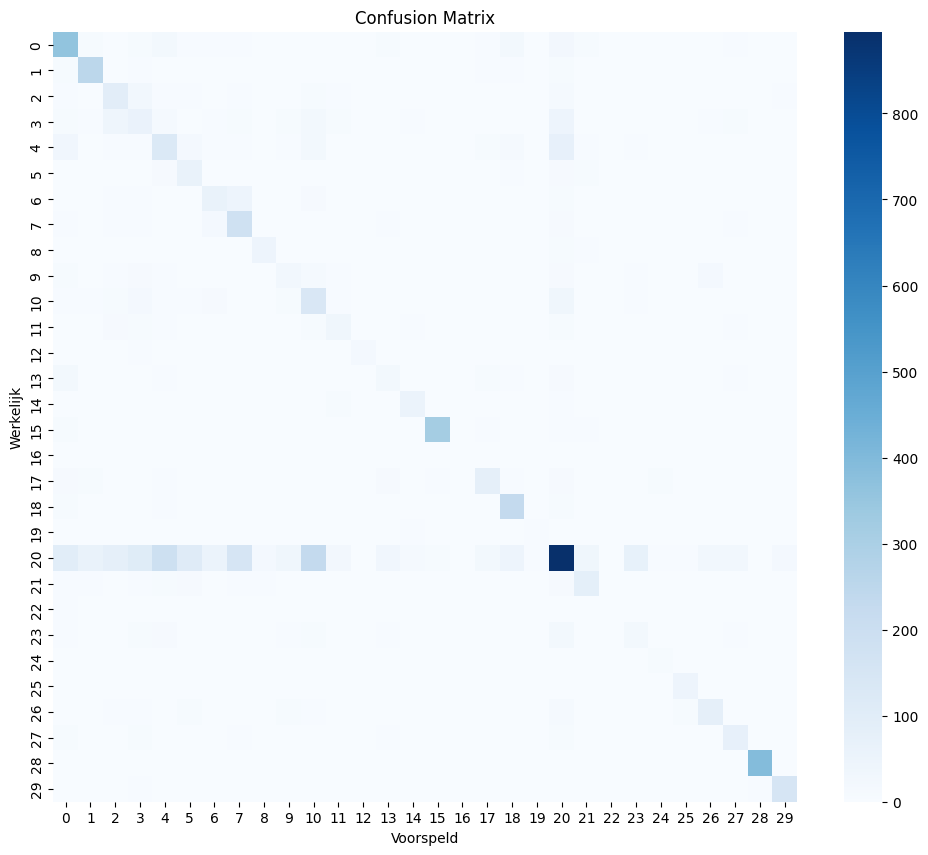

In [21]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Voorspeld")
plt.ylabel("Werkelijk")
plt.title("Confusion Matrix")
plt.show()


In [22]:
unique, counts = np.unique(preds, return_counts=True)
pred_dist = pd.DataFrame({
    "label_id": unique,
    "pred_count": counts,
    "pred_pct": counts / counts.sum()
}).sort_values("pred_pct", ascending=False)

pred_dist["label_name"] = pred_dist["label_id"].map(lambda i: le.classes_[i])
pred_dist.head(15)


,label_id,pred_count,pred_pct,label_name
20,20,1272,0.172311,['neutral']
0,0,616,0.083446,['admiration']
10,10,493,0.066784,['disapproval']
7,7,434,0.058792,['curiosity']
4,4,433,0.058656,['approval']
28,28,407,0.055134,hateful
1,1,364,0.049309,['amusement']
15,15,349,0.047277,['gratitude']
18,18,347,0.047006,['love']
3,3,308,0.041723,['annoyance']
